In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_June2024_Tier1.csv")

coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

    if regression:
        model_type = 'Reg'
    else:
        model_type = 'CNN'
    
    results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
    results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]


def differences_significant_CNN_Reg(df, model, variable, direction='two-sided'):

    results_1 = df.query("Model=='CNN' & Addl_Data==@model")[variable].values
    results_2 = df.query("Model=='Reg' & Addl_Data==@model")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cryptic_wgs_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")
df_cryptic = pd.read_csv("MIC_data/CRyPTIC_reuse_table_20231208.csv")
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_WHO_catalog_variants.csv")).dropna(subset='variant').reset_index(drop=True)

/tmp/ipykernel_16286/1932288502.py:8: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


In [7]:
cass_mapping_table = pd.read_csv("/home/sak0914/data_cleaning/cass_mapping_table.txt")

In [11]:
cass_mapping_table.loc[cass_mapping_table['Run'].isin(['SRR10869030', 'SRR10869302', 'SRR10869310'])][['BioSample', 'Run', 'Sample Name', 'isolate']]

,BioSample,Run,Sample Name,isolate
67,SAMN13813754,SRR10869030,C228,C041
339,SAMN13813833,SRR10869302,C469,C120
347,SAMN13813727,SRR10869310,C098,C014


In [2]:
isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

In [3]:
isolate_metadata.query("RUN in ['SRR10869030', 'SRR10869302', 'SRR10869310']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,OtherNames
74,C098,SAMN13813727,SRS5977575,SRR10869310,CASS,2019,South Africa,South Africa,1,1,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,4/28/20 13:17,1/10/20 13:35,SRR10869310,1.0,NaN
172,C228,SAMN13813754,SRS5977855,SRR10869030,CASS,2019,South Africa,South Africa,1,1,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,4/28/20 13:17,1/10/20 13:27,SRR10869030,1.0,NaN
347,C469,SAMN13813833,SRS5977583,SRR10869302,CASS,2019,South Africa,South Africa,1,1,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,4/28/20 13:17,1/10/20 13:35,SRR10869302,1.0,NaN


# Quantitative Model Comparison

In [4]:
def get_all_single_drug_models(drug, regression=False):
    '''
    This function gets all the models for a given drug that have model results
    '''

    # gets all directories with the drug name
    CNN_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/results.csv"))
    
    # if regression or bootstrap, then all directories must also have those corresponding directories. The regression script performs bootstrapping, so don't need to check them separately
    if regression:
        regression_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/ridge/results.csv"))
    else:
        regression_fNames = []
        
    df_combined = []
    
    for fName in CNN_fNames + regression_fNames:
        
        df = pd.read_csv(fName)
        
        model_name = '- Lineage'
    
        num_addl_features = 0
    
        if 'lineage' in fName:
            # model_name += '\n+Lineage'
            model_name = '+ Lineage'
            num_addl_features += 1
    
        if 'amino_acid' not in fName:
            model_name += '\n- AA Properties'
            num_addl_features += 1
    
        if 'tier2' in fName:
            model_name += '\n+ Tier 2 Loci'
            num_addl_features += 1
        
        # remove leading newline characters
        model_name = model_name.lstrip()
            
        df['Addl_Data'] = model_name
        df_combined.append(df)

    df_combined = pd.concat(df_combined)

    # check no duplicate row identifiers
    assert len(df_combined[['Model', 'Addl_Data', 'CV']].drop_duplicates()) == len(df_combined)

    # exponentiate errors
    for col in ['Binned_MAE', 'Binned_MSE']:
        df_combined[f'{col}_exp'] = np.exp2(df_combined[col])

    # add
    df_combined['Without_doubling'] = 1 - df_combined['Within_doubling']

    return df_combined

In [5]:
def plot_single_drug_model_comparison(drug, df_combined, plot_col='Binned_MAE_exp', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    color_palette = dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex()))

    if model_order is None:
        model_order = ['- Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    df_combined['Model'] = df_combined['Model'].replace('Reg', 'Regression')

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=['Regression', 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate(['Regression', 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    plt.legend(title='', fontsize=ref_font_size-1, loc='best', ncols=2)
    
    # try:
    #     ax.get_legend().remove()
    # except:
    #     pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

In [6]:
def get_performance_comparison_CNN_Reg(drug, model_order=None, plot_col='Binned_MAE', plot=True):
    
    df_combined = get_all_single_drug_models(drug, regression=True)

    if model_order is None:
        model_order = ['- Lineage', '+ Lineage', '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci'] #['+AA Properties', '+Lineage\n+AA Properties']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")
    
    if 'exp' in plot_col.lower():
        plot_y_min = 1
        title = 'Mean Absolute Error (Doublings)'
        ylabel = 'Relative Error'
        save_name = 'MAE_exp'
    elif 'doubling' in plot_col.lower():
        plot_y_min = 0
        title = 'Essential Disagreement'
        ylabel = 'Essential Disagreement'
        save_name = 'EA'
    else:
        plot_y_min = 0
        title = 'Mean Absolute Error'
        ylabel = 'Mean Absolute Error (log2-MIC)'
        save_name = 'MAE'

    if '- Lineage\n+ Tier 2 Loci' in model_order:
        save_name += "_tier2"

    if plot:
        plot_single_drug_model_comparison(drug, df_combined, plot_col=plot_col, model_order=model_order, mean_bar_width=0.15, y_min=plot_y_min, ylabel=ylabel, title=title, saveName=f"results/{abbr_drug_dict[drug]}/{save_name}.svg")
        
        # plot_single_drug_model_comparison(drug, df_combined, plot_col='Without_doubling', model_order=model_order, mean_bar_width=0.15, y_min=0, ylabel='Essential Disagreement (%)', title='Percent of Predictions >1 Doubling Away', saveName=f"results/{abbr_drug_dict[drug]}/EA.svg")
            
    df_pvals = pd.DataFrame(columns=['Model', 'Variable', 'CNN_better_pval', 'Reg_better_pval'])
    i = 0

    for model in df_combined.Addl_Data.unique():
        df_pvals.loc[i, :] = [model.replace('\n', ','), 
                              plot_col, 
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='less'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='greater')
                             ]
        i += 1
        
        # df_pvals.loc[i, :] = [model.replace('\n', ','), 
        #                       'Without_doubling',
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='less'),
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='greater')
        #                      ]
        # i += 1

    # # perform FDR correction at the single-drug level
    # _, cnn_better_bh_pvals, _, _ = sm.multipletests(df_pvals['CNN_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_CNN_better_pval'] = cnn_better_bh_pvals
    
    # _, reg_better_bh_pvals, _, _ = sm.multipletests(df_pvals['Reg_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_Reg_better_pval'] = reg_better_bh_pvals
    
    df_pvals['Drug'] = drug
    
    return df_combined, df_pvals

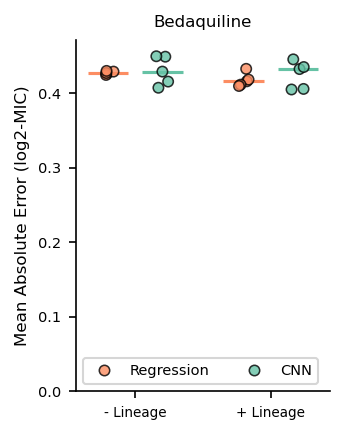

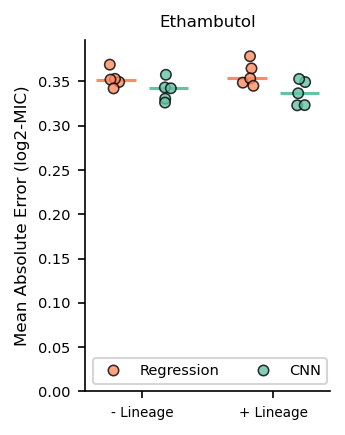

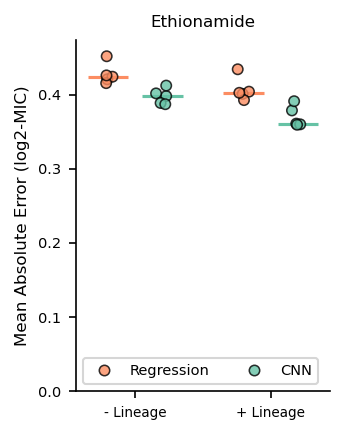

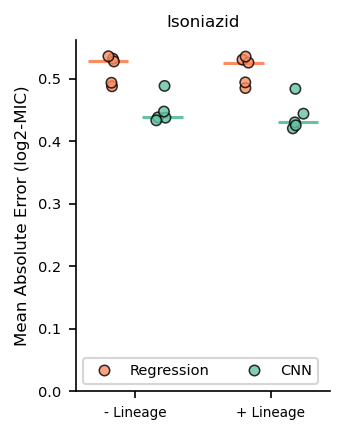

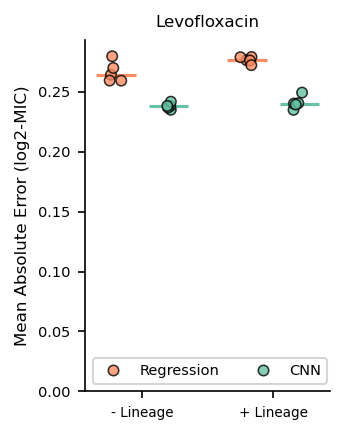

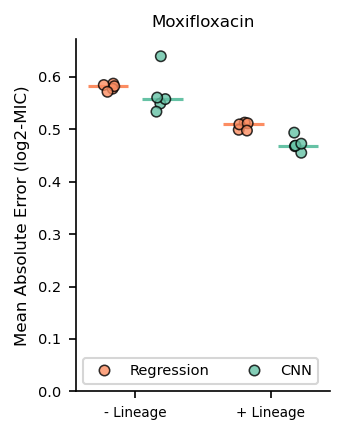

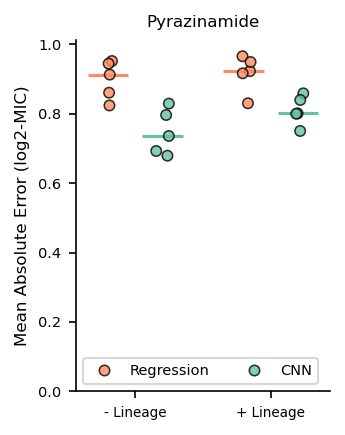

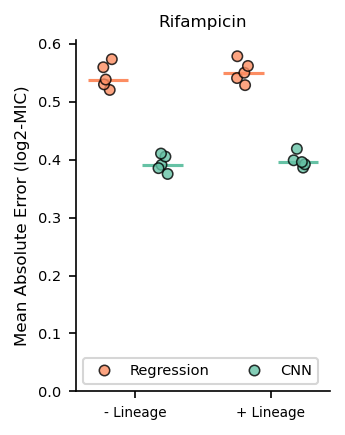

In [7]:
df_results_combined = []
df_pvals_combined = []

for drug in os.listdir(data_dir):

    df_results, df_pvals = get_performance_comparison_CNN_Reg(drug, model_order=['- Lineage', '+ Lineage'], plot_col='Binned_MAE', plot=True)
    df_results_combined.append(df_results)
    df_pvals_combined.append(df_pvals)

df_results_combined = pd.concat(df_results_combined)
df_pvals_combined = pd.concat(df_pvals_combined)

In [10]:
df_pvals_combined.query("Drug=='ETH'")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,- Lineage,Binned_MAE,0.002847,0.997153,ETH
1,+ Lineage,Binned_MAE,0.002488,0.997512,ETH


In [87]:
# CNN_error_summary = pd.DataFrame(df_results_combined.query("Model=='CNN'").groupby(['Drug', 'Addl_Data'])[['Binned_MAE', 'Binned_MAE_exp', 'Without_doubling']].mean()).reset_index().sort_values('Drug')

# CNN_error_summary['Drug'] = CNN_error_summary['Drug'].map(abbr_drug_dict)

# CNN_error_summary['Within_doubling_perc'] = (1 - CNN_error_summary['Without_doubling']) * 100

# # binned MAE exp is the relative error, y_true / y_pred. Divide by 2 to get doublings
# CNN_error_summary['Doubling_Error'] = CNN_error_summary['Binned_MAE_exp'] / 2

# CNN_error_summary.sort_values(['Drug', 'Addl_Data'], ascending=[True, False]).to_csv("results/tables/model_performances.csv", index=False)

CNN_error_summary = pd.read_csv("results/tables/model_performances.csv")

In [88]:
CNN_error_summary.Within_doubling_perc.min(), CNN_error_summary.query("Drug != 'Pyrazinamide'").Within_doubling_perc.min(), CNN_error_summary.Within_doubling_perc.max()

(74.42622950819671, 80.80347448425624, 91.40969162995594)

In [89]:
# save the full results to the supplement
del_cols = ['Num_Loci', 'Spearman', 'Pearson', 'F1', 'MAE', 'MSE']

for col in del_cols:
    if col in df_results_combined.columns:
        del df_results_combined[col]

In [90]:
CNN_error_summary['Binned_MAE'].min(), CNN_error_summary['Binned_MAE'].max()

(0.2378607481221121, 0.8096107407249404)

In [91]:
CNN_error_summary['Doubling_Error'].min(), CNN_error_summary['Doubling_Error'].max()

(0.5896220783338084, 0.8766632025548375)

In [93]:
# regression is never better in MAE
df_pvals_combined.query("Variable == 'Binned_MAE' & Reg_better_pval <= 0.05").sort_values("Reg_better_pval", ascending=False)

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug


In [94]:
df_pvals_combined.query("CNN_better_pval <= 0.05").CNN_better_pval.max()

0.02130825674282059

In [95]:
df_pvals_combined.query("CNN_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,- Lineage,Binned_MAE,0.617167,0.382833,BDQ
1,+ Lineage,Binned_MAE,0.766607,0.233393,BDQ
0,- Lineage,Binned_MAE,0.05024,0.94976,EMB
0,- Lineage,Binned_MAE,0.268507,0.731493,MXF


In [96]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='BDQ'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.7656664094822963

In [97]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='BDQ'"), '+ Lineage', 'Binned_MAE', direction='two-sided')

0.4667862582483223

In [98]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='EMB'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.10047966656658035

In [99]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='MXF'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.5370141579998038

In [15]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='ETH'"), '+ Lineage', 'Binned_MAE', direction='less')

0.0024875345788680767

In [17]:
differences_significant_two_models(df_results_combined.query("Drug=='ETH'"), '+ Lineage', '- Lineage', 'Binned_MAE', regression=False, direction='less')

0.004716034198523342

# Pyrazinamide -/+ AA

In [117]:
PZA_lineage = pd.read_csv(f"{results_dir}/PZA_lineage/results.csv")
PZA_lineage_AA = pd.read_csv(f"{results_dir}/PZA_lineage_amino_acid/results.csv")

PZA_lineage['Binned_MAE'].mean(), PZA_lineage_AA['Binned_MAE'].mean()

st.ttest_ind(PZA_lineage['Binned_MAE'], PZA_lineage_AA['Binned_MAE'], equal_var=False, alternative='greater')

TtestResult(statistic=1.2516425606120667, pvalue=0.13730298511642378, df=4.290054698841493)

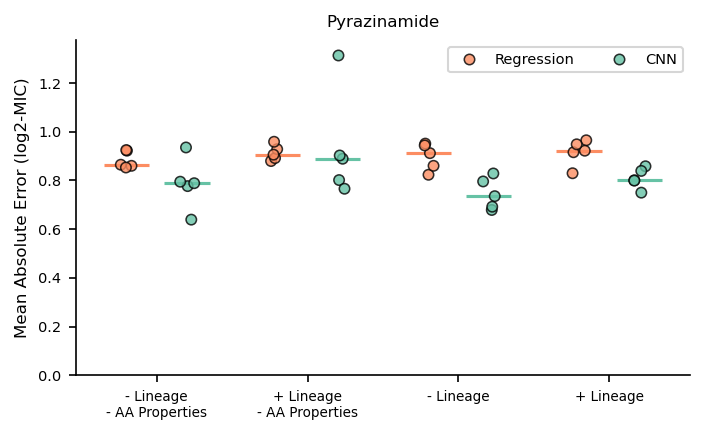

In [129]:
df_PZA_no_AA, df_pvals = get_performance_comparison_CNN_Reg('PZA', model_order=['- Lineage\n- AA Properties', '+ Lineage\n- AA Properties', '- Lineage', '+ Lineage'], plot_col='Binned_MAE', plot=True)

# Ethionamide Tier 2

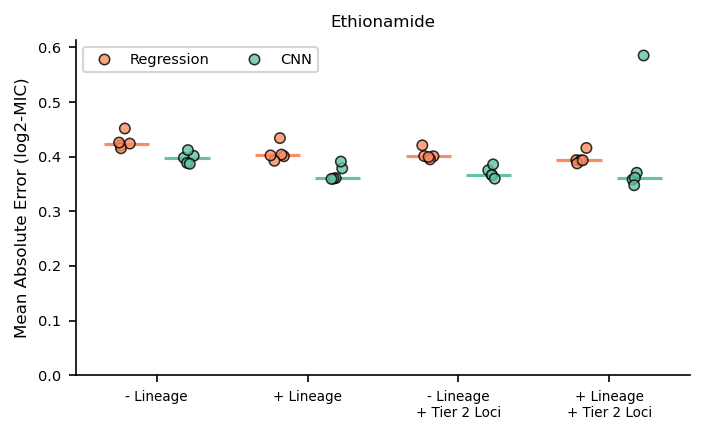

In [20]:
df_ETH_tier2, df_pvals = get_performance_comparison_CNN_Reg('ETH', model_order=None, plot_col='Binned_MAE', plot=True)

In [130]:
df_ETH_tier2.query("Model=='CNN'").groupby('Addl_Data')[['Binned_MAE', 'Without_doubling']].mean()

,Binned_MAE,Without_doubling
Addl_Data,,
+ Lineage,0.369961,0.116409
+ Lineage\n+ Tier 2 Loci,0.394422,0.126641
- Lineage,0.397494,0.121622
- Lineage\n+ Tier 2 Loci,0.370918,0.121236


In [131]:
1-0.121236

0.878764

In [19]:
differences_significant_two_models(df_ETH_tier2, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci', 'Binned_MAE')

0.27227726677435066

In [25]:
differences_significant_two_models(df_ETH_tier2, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci', 'Without_doubling')

0.7360032520816141

In [20]:
differences_significant_two_models(df_ETH_tier2, '+ Lineage', '+ Lineage\n+ Tier 2 Loci', 'Binned_MAE')

0.6137174526833371

In [26]:
differences_significant_two_models(df_ETH_tier2, '+ Lineage', '+ Lineage\n+ Tier 2 Loci', 'Without_doubling')

0.4700336710783527

# CNN Performance Comparisons +/- Lineage

In [30]:
def get_performance_comparison_lineage(drug, variable, regression=False):
    
    df_combined = get_all_single_drug_models(drug, regression=True)

    if regression:
        df_combined = df_combined.query("Model=='Reg'")
    else:
        df_combined = df_combined.query("Model=='CNN'")


    df_pvals = pd.DataFrame(columns=['Variable', 'Lineage_Better_pval', 'Lineage_Worse_pval', 'Mean_Diff'])
    i = 0

    for variable in ['Binned_MAE', 'Without_doubling']:
        
        df_pvals.loc[i, :] = [variable,        
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='less'),
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='greater'),
                              np.abs(df_combined.query("Addl_Data == '+ Lineage'")[variable].mean() - df_combined.query("Addl_Data == '- Lineage'")[variable].mean())
                             ]


    for variable in ['Binned_MAE', 'Without_doubling']:
        
        df_pvals.loc[i, :] = [variable,        
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='less'),
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='greater'),
                              np.abs(df_combined.query("Addl_Data == '+ Lineage'")[variable].mean() - df_combined.query("Addl_Data == '- Lineage'")[variable].mean())
                             ]

        i += 1
            
    df_pvals['Drug'] = drug
    return df_pvals

In [31]:
df_pvals_lineage_comparison = []

for drug in os.listdir(data_dir):
    try:
        df_pvals_lineage_comparison.append(get_performance_comparison_lineage(drug, 'Without_doubling', regression=False))
    except:
        print(f"{drug} not finished")

df_pvals_lineage_comparison = pd.concat(df_pvals_lineage_comparison)

In [32]:
df_pvals_lineage_comparison.query("Lineage_Better_pval <= 0.05 | Lineage_Worse_pval <= 0.05")

,Variable,Lineage_Better_pval,Lineage_Worse_pval,Mean_Diff,Drug
0,Binned_MAE,0.005079,0.994921,0.026489,ETH
1,Within_doubling,0.995908,0.004092,0.016433,ETH
0,Binned_MAE,0.002246,0.997754,0.096393,MXF
1,Within_doubling,0.999974,0.000026,0.050923,MXF


In [33]:
df_pvals_lineage_comparison.query("Lineage_Better_pval <= 0.1 | Lineage_Worse_pval <= 0.1")

,Variable,Lineage_Better_pval,Lineage_Worse_pval,Mean_Diff,Drug
1,Within_doubling,0.084875,0.915125,0.003304,BDQ
0,Binned_MAE,0.005079,0.994921,0.026489,ETH
1,Within_doubling,0.995908,0.004092,0.016433,ETH
0,Binned_MAE,0.002246,0.997754,0.096393,MXF
1,Within_doubling,0.999974,0.000026,0.050923,MXF
0,Binned_MAE,0.944615,0.055385,0.063263,PZA
1,Within_doubling,0.085704,0.914296,0.025137,PZA


In [34]:
df_pvals_lineage_comparison.query("Drug=='PZA'")

,Variable,Lineage_Better_pval,Lineage_Worse_pval,Mean_Diff,Drug
0,Binned_MAE,0.944615,0.055385,0.063263,PZA
1,Without_doubling,0.914296,0.085704,0.025137,PZA


# Loss Curves

Plot validation loss for the 5 CV replicates and the actual model on top. 

In [18]:
def plot_histories(path, patience_epochs=200, cv=True, saveName=None):

    if cv:
        combined_replicates = [pd.read_csv(fName)[['val_loss']] for fName in glob.glob(os.path.join(path, f"cross_validation/history*.csv"))]
    
    history = pd.read_csv(os.path.join(path, "history.csv"))

    if patience_epochs != 0:
        history = history.iloc[:-patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    if cv:
        for i, single_rep in enumerate(combined_replicates):

            if patience_epochs !=  0:
                single_rep = single_rep.iloc[:-patience_epochs, :]
                
            print(f"Trained replicate {i} for {len(single_rep)} epochs")
            
            plt.plot(single_rep.index.values + 1, single_rep['val_loss'], color="lightgray")

    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)
    print(f"Trained full model for {len(history)} epochs")

    plt.xlabel("Epoch", fontsize=10)
    plt.ylabel("Validation Loss", fontsize=10)
    
    plot_title = "Validation Loss" + " for " + os.path.basename(path) + " Model"
    plt.title(plot_title, fontsize=12)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName)


BDQ
Trained replicate 0 for 249 epochs
Trained replicate 1 for 202 epochs
Trained replicate 2 for 233 epochs
Trained replicate 3 for 245 epochs
Trained replicate 4 for 209 epochs
Trained full model for 585 epochs

EMB
Trained replicate 0 for 520 epochs
Trained replicate 1 for 420 epochs
Trained replicate 2 for 328 epochs
Trained replicate 3 for 464 epochs
Trained replicate 4 for 249 epochs
Trained full model for 447 epochs

ETH
Trained replicate 0 for 511 epochs
Trained replicate 1 for 426 epochs
Trained replicate 2 for 538 epochs
Trained replicate 3 for 622 epochs
Trained replicate 4 for 326 epochs
Trained full model for 532 epochs

INH
Trained replicate 0 for 651 epochs
Trained replicate 1 for 603 epochs
Trained replicate 2 for 665 epochs
Trained replicate 3 for 250 epochs
Trained replicate 4 for 503 epochs
Trained full model for 424 epochs

LEV
Trained replicate 0 for 405 epochs
Trained replicate 1 for 391 epochs
Trained replicate 2 for 462 epochs
Trained replicate 3 for 360 epochs

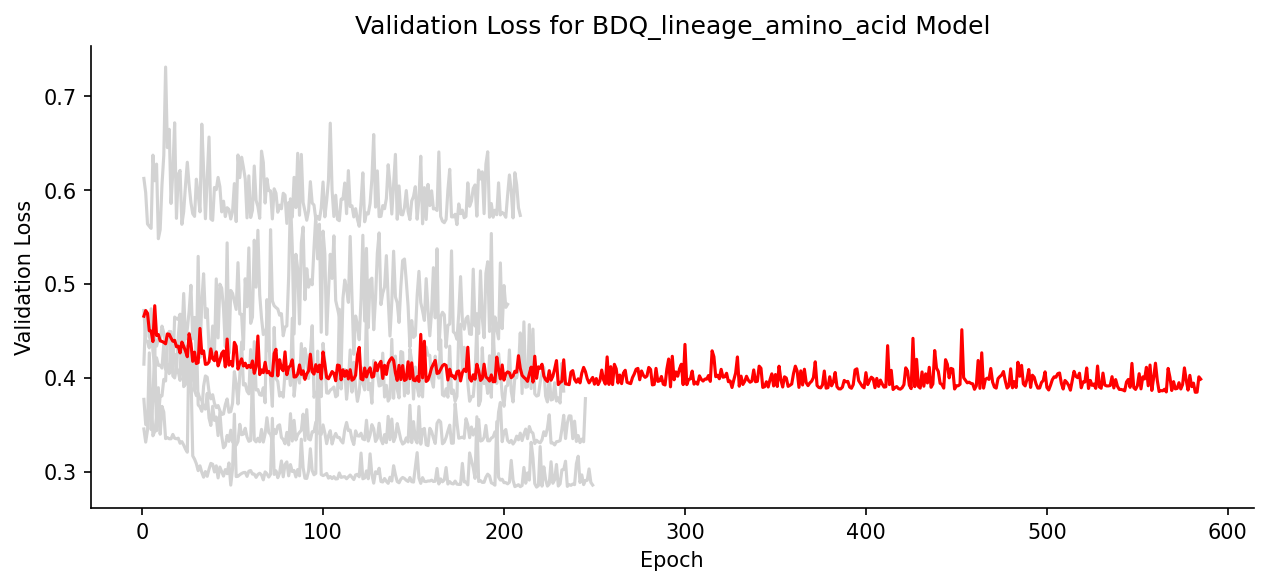

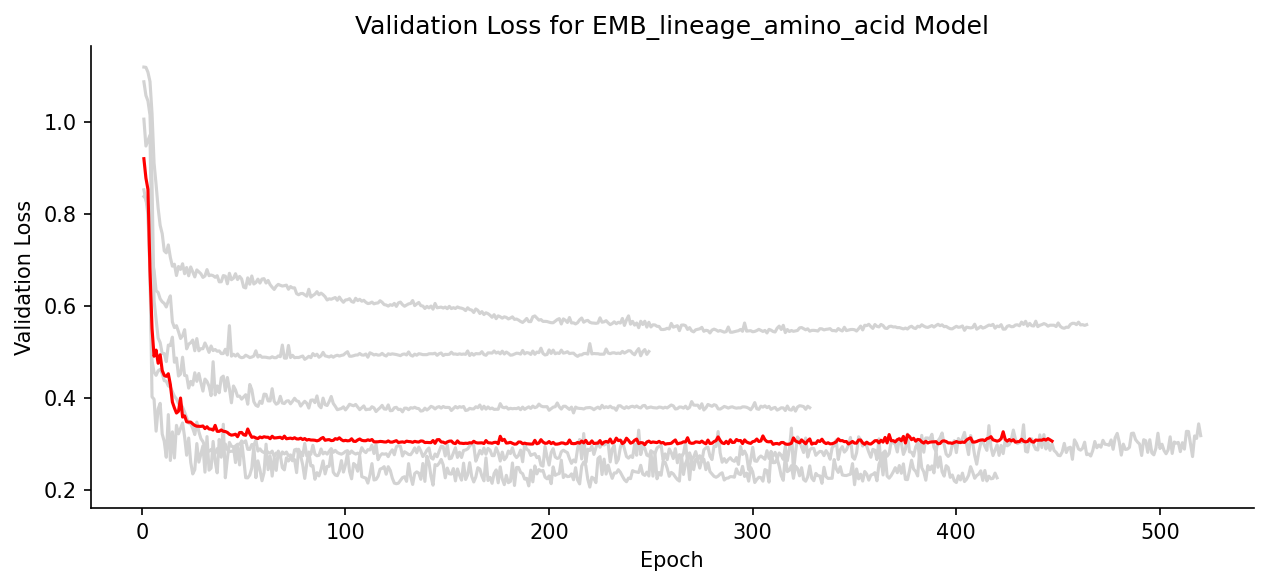

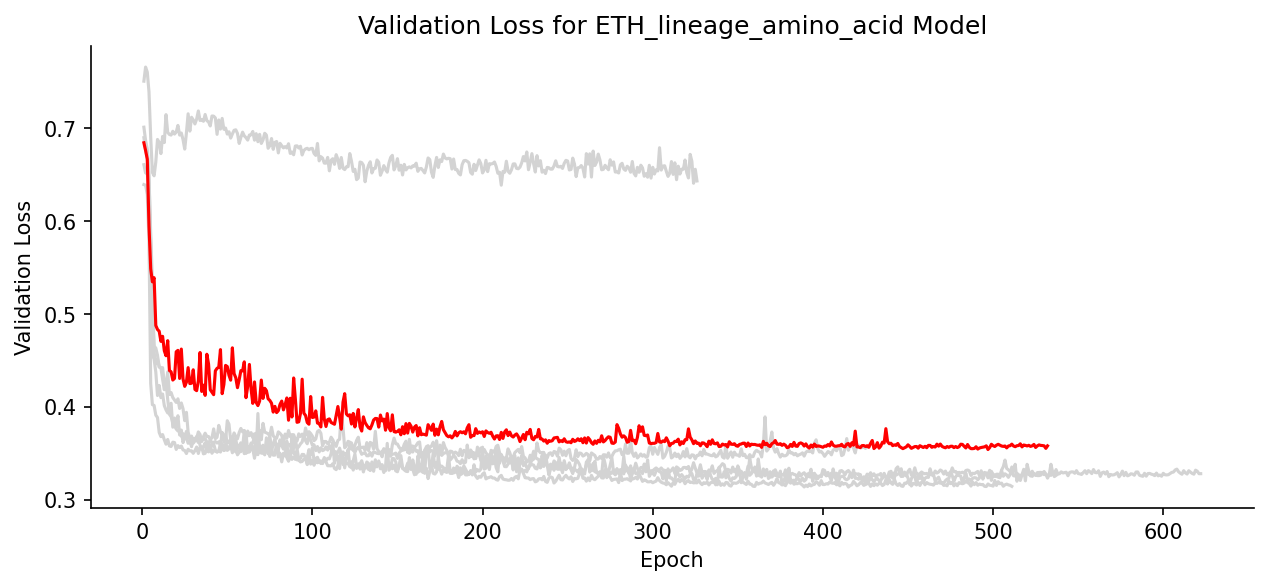

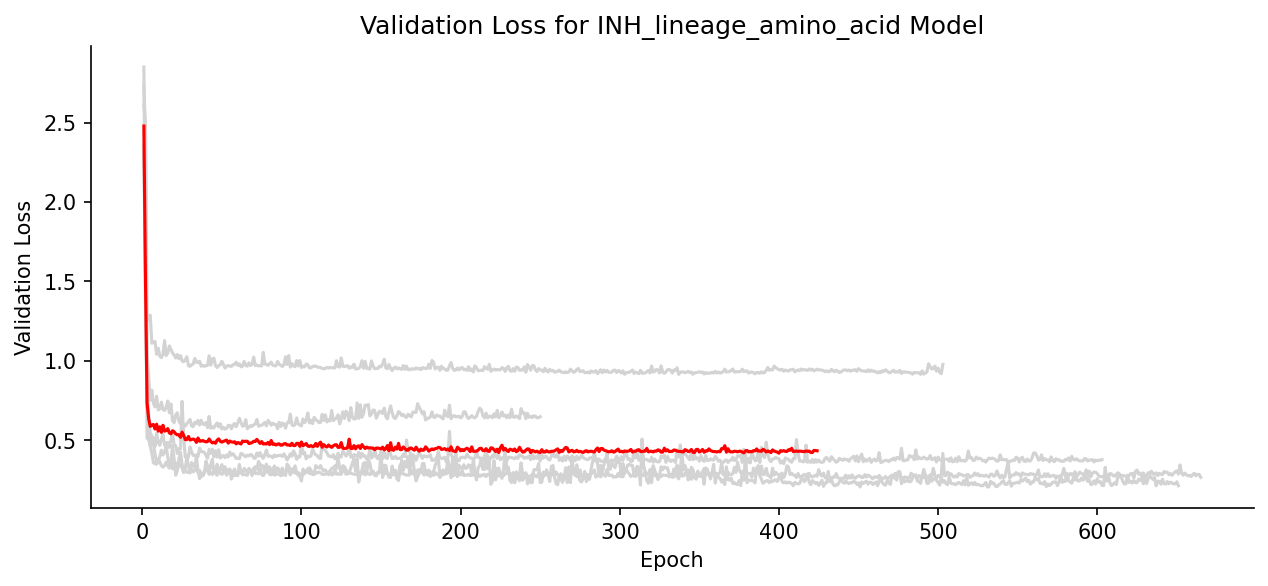

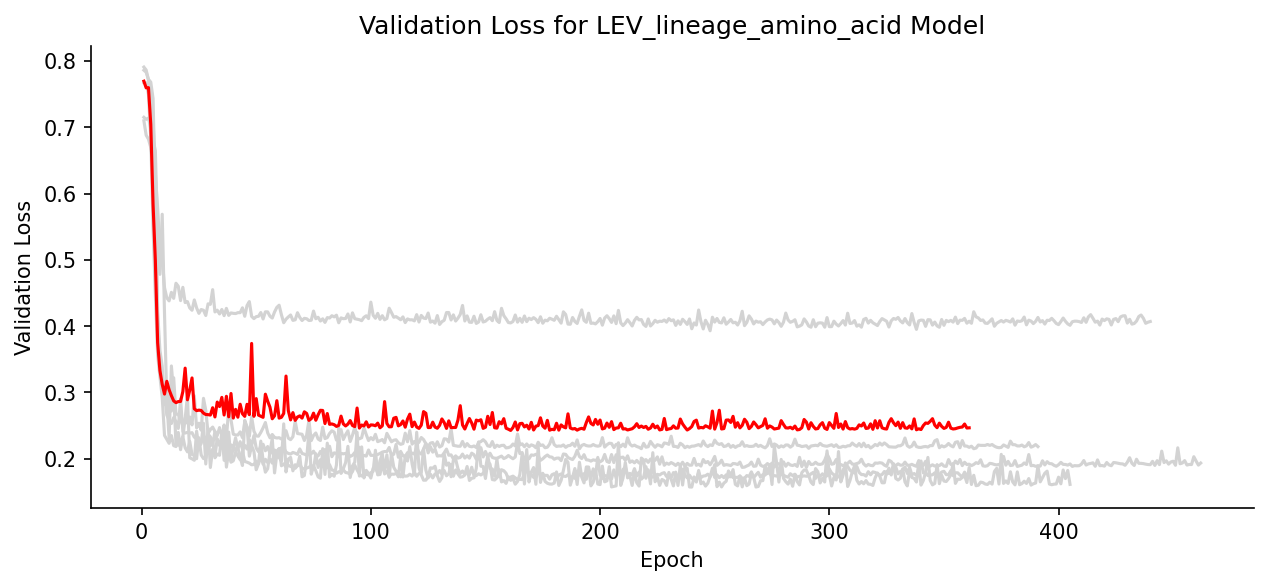

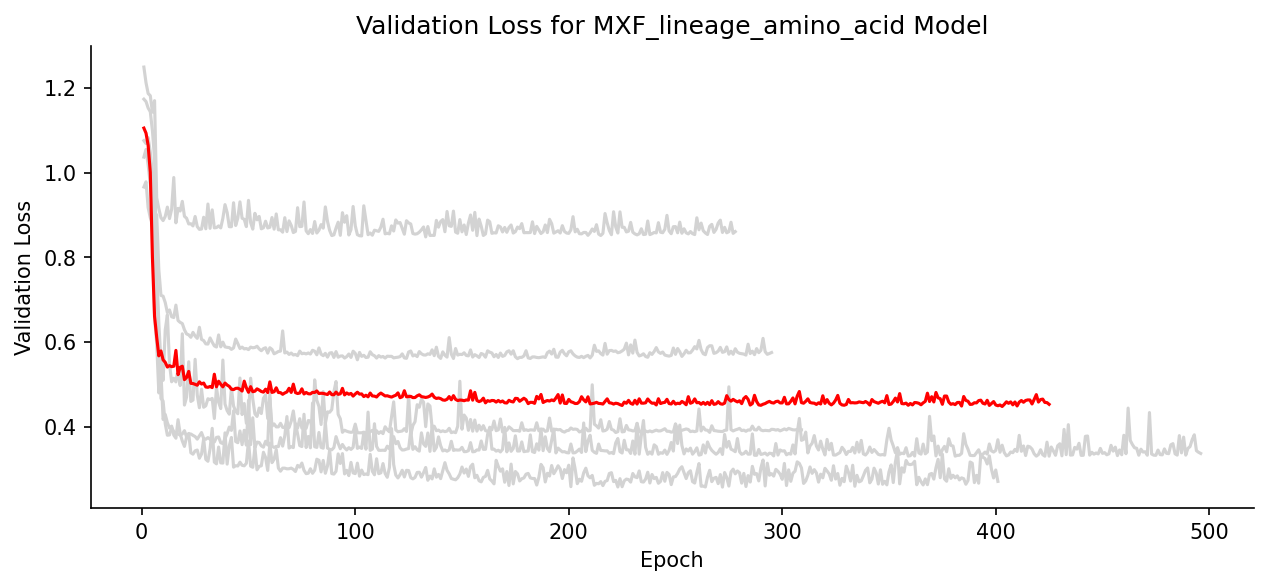

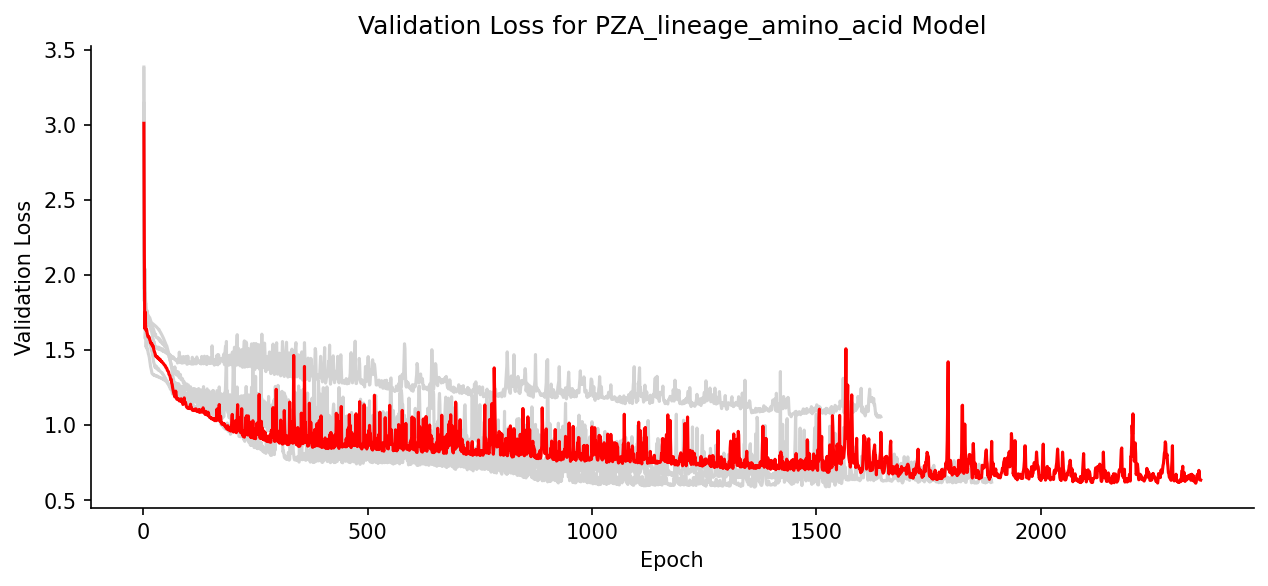

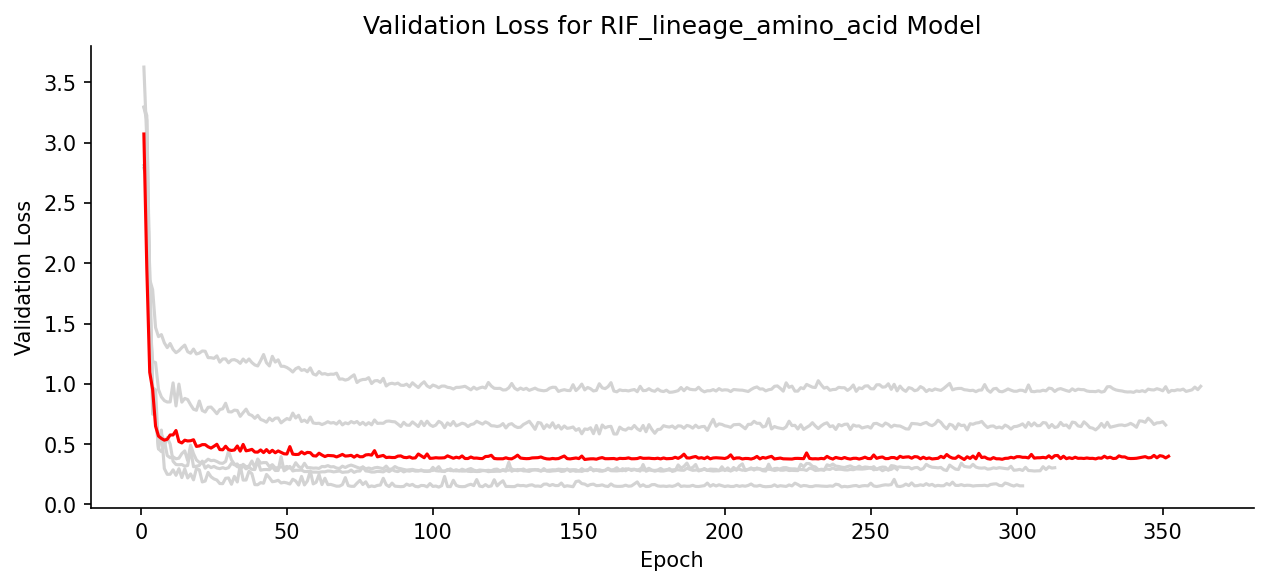

In [19]:
for drug in os.listdir(data_dir):
    print(f"\n{drug}")
    plot_histories(os.path.join(results_dir, f'{drug}_lineage_amino_acid'), patience_epochs=0, cv=True, saveName=f"results/{abbr_drug_dict[drug]}/loss_curves.svg")

In [101]:
# plot_histories(os.path.join(results_dir, "PZA_peptide_amino_acid"), binary=False, patience_epochs=150, replicates=True)

In [102]:
# plot_histories(os.path.join(results_dir, "PZA_peptide"), binary=False, patience_epochs=150, replicates=True)

# Binary Statistics: Compare with 2023 WHO Catalog

## Predicted R if any 1) Assoc w R or 2) Assoc w R - Interim mutation is present

In [2]:
def compute_t_dist_confidence_interval(cv_results_df, alpha=0.05):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc']
    
    # keep only the metrics of interest
    df_cv_metrics = pd.DataFrame(cv_results_df[metrics_lst].mean()).reset_index()

    # the mean is the test value
    df_cv_metrics.columns = ['Metric', 'Test']

    # compute standard deviation and standard error = SD / sqrt(n)
    df_std = pd.DataFrame(cv_results_df[metrics_lst].std()).reset_index()
    df_std.columns = ['Metric', 'SD']
    df_std['STD_error'] = df_std['SD'] / np.sqrt(len(cv_results_df))

    # get the critical value. Because there are 5 CV splits, and this is < 30, use the t distribution, not the standard normal
    confidence = 1 - alpha
    t_value = st.t.ppf((1 + confidence) / 2., len(cv_results_df) - 1)

    df_cv_metrics = df_cv_metrics.merge(df_std)
    df_cv_metrics['Low'] = df_cv_metrics['Test'] - t_value * df_cv_metrics['STD_error']
    df_cv_metrics['High'] = df_cv_metrics['Test'] + t_value * df_cv_metrics['STD_error']

    return df_cv_metrics[['Metric', 'Test', 'Low', 'High']]
    
    
    
def compute_exact_confidence_intervals_binary_stats(pred_df, cc, binarize=False, alpha=0.05):

    if binarize:
        pred_df['y_pred'] = (np.exp2(pred_df['y_pred']) > cc).astype(int)
        pred_df['y_test'] = (pred_df['upper'] > cc).astype(int)

    tp = len(pred_df.query("y_pred==1 & y_test==1"))
    tn = len(pred_df.query("y_pred==0 & y_test==0"))
    fn = len(pred_df.query("y_pred==0 & y_test==1"))
    fp = len(pred_df.query("y_pred==1 & y_test==0"))
    
    assert tp + tn + fn + fp == len(pred_df)

    # possible that tp + fp = 0 (meaning nothing was predicted resistant), so make ppv 0 if so, otherwsie get a divide by 0 error for ppv
    if tp + fp == 0:
        ppv = 0
    else:
        ppv = tp / (tp + fp)

    metrics_df = pd.DataFrame({'Metric': ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc', 'F1'],
                               'Test': [tp / (tp + fn), # sensitivity
                                       tn / (tn + fp), # specificity
                                       ppv, # precision (ppv)
                                       (tp + tn) / (tp + tn + fp + fn), # accuracy
                                       0.5 * (tp / (tp + fn) + tn / (tn + fp)), # balanced accuracy
                                       tp / (tp + 0.5*(fp + fn)), # F1 score
                                       ]
                             }).set_index('Metric')

    # sensitivity
    ci = st.binomtest(k=tp, n=tp + fn, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Sensitivity', ['Low', 'High']] = [ci.low, ci.high]
    
    # specificity
    ci = st.binomtest(k=tn, n=tn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Specificity', ['Low', 'High']] = [ci.low, ci.high]
    
    # precision (ppv)
    if tp + fp == 0:
        metrics_df.loc['Precision', ['Low', 'High']] = [0, 0]
    else:
        ci = st.binomtest(k=tp, n=tp + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
        metrics_df.loc['Precision', ['Low', 'High']] = [ci.low, ci.high]
    
    # accuracy
    ci = st.binomtest(k=tp + tn, n=tp + tn + fn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Accuracy', ['Low', 'High']] = [ci.low, ci.high]
    
    # balanced accuracy
    ci = st.binomtest(k=tp*tn + tp*fp + tn*tp + tn*fn, n=2 * (tp + fn) * (tn + fp), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Balanced_Acc', ['Low', 'High']] = [ci.low, ci.high]
    
    # F1 score
    ci = st.binomtest(k=tp, n=int(tp + 0.5*(fp + fn)), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['F1', ['Low', 'High']] = [ci.low, ci.high]
    
    assert sum(metrics_df['Test'] < metrics_df['Low']) == 0
    assert sum(metrics_df['Test'] > metrics_df['High']) == 0

    return metrics_df.reset_index()
    
    
    
def single_drug_binary_results(model_path, cc, V1=False, alpha=0.05):

    drug = model_path.split('_')[0]

    catalog_fName = os.path.join(results_dir, drug, "catalog_test_predictions_V2.csv")

    if V1:
        catalog_fName = catalog_fName.replace('V2', 'V1')

    # if AF_thresh != 0.75:
    #     catalog_fName = '.'.join(catalog_fName.split(".")[:-1]) + f"_AF_thresh_{int(AF_thresh*100)}." + catalog_fName.split(".")[-1]
    #     cnn_fName = os.path.join(results_dir, model_path, f"test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    #     reg_fName = os.path.join(results_dir, model_path, f"ridge/test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    # else:
    cnn_fName = os.path.join(results_dir, model_path, "results.csv")
    reg_fName = os.path.join(results_dir, model_path, "ridge", "results.csv")
    
    catalog_predictions = pd.read_csv(catalog_fName)
    catalog_metrics_df = compute_exact_confidence_intervals_binary_stats(catalog_predictions, cc, alpha=alpha)

    # cnn_predictions = pd.read_csv(os.path.join(results_dir, model_path, "test_predictions.csv"))
    # reg_predictions = pd.read_csv(os.path.join(results_dir, model_path, "ridge", "test_predictions.csv"))
    # cnn_metrics_df = compute_exact_confidence_intervals_binary_stats(cnn_predictions, cc, binarize=True, alpha=alpha)
    # reg_metrics_df = compute_exact_confidence_intervals_binary_stats(reg_predictions, cc, binarize=True, alpha=alpha)

    # use the CV results and compute 95% confidence intervals using the t stat
    cnn_results = pd.read_csv(cnn_fName)
    reg_results = pd.read_csv(reg_fName)
    cnn_metrics_df = compute_t_dist_confidence_interval(cnn_results, alpha=alpha)
    reg_metrics_df = compute_t_dist_confidence_interval(reg_results, alpha=alpha)

    catalog_metrics_df['Model'] = 'Catalog'
    cnn_metrics_df['Model'] = 'CNN'
    reg_metrics_df['Model'] = 'Regression'

    return pd.concat([catalog_metrics_df, cnn_metrics_df, reg_metrics_df], axis=0)



def plot_single_drug_all_metrics(model_path, cc, save=False, V1=False):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision', 'F1']
    
    drug = model_path.split("_")[0]

    # get binary metrics and exact confidence intervals
    df_metrics = single_drug_binary_results(model_path, cc, V1=V1)

    categories = ['Catalog', 'Regression', 'CNN']
    df_metrics = df_metrics.set_index(["Model", "Metric"])
    
    palette=dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex()))

    # Bar width and positions
    bar_width = 0.05
    # bar_positions = np.arange(len(categories))
    
    errwidth = 0.04
    errlinewidth = 0.5
    
    fig, axs = plt.subplots(1, len(metrics_lst), figsize=(len(metrics_lst)*2, 3), sharex=True, sharey=True)
    axs = axs.flatten()

    for i, metric in enumerate(metrics_lst):

        ax = axs[i]
        
        # Plot bars for each category
        for j, category in enumerate(categories):
        
            # plot_df.loc['Catalog', 'Sensitivity']['Test']
            
            test = df_metrics.loc[category, metric]["Test"] * 100
            lower = df_metrics.loc[category, metric]["Low"] * 100
            upper = df_metrics.loc[category, metric]["High"] * 100
            
            # Plot the test value as a bar
            patch = ax.bar(j, test, color=palette[category], label=category, linewidth=0.5, edgecolor='black')
            ax.bar_label(patch, label_type='center', fmt='%.1f', fontsize=9)
            
            # Plot the confidence interval as a vertical line
            ax.vlines(j, lower, upper, color='black', linewidth=errlinewidth)
        
            # plot horizontal lines to make the error bars look nicer
            ax.hlines(lower, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
            ax.hlines(upper, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
        
        ax.set_title(metric, fontsize=10)
        
        # remove x-axis ticks and labels
        ax.set_xticks([])
        ax.set_xticklabels([])
    
    # Show the plot
    plt.ylim(0, 100)
    plt.suptitle(f"{abbr_drug_dict[drug]}\n\n", y=1.02)
    plt.legend(bbox_to_anchor=(0.2, -0.15), loc="lower right", ncol=len(categories), fontsize=8)
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"results/{abbr_drug_dict[drug]}/binary_metrics_comparison.svg", bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [3]:
def plot_single_metric_all_drugs(metric, save=False, V1=False):

    df_metrics_all_drugs = []
    
    for drug in np.sort(os.listdir(data_dir)):

        # model_path = f"{drug}_amino_acid"
        
        if drug == 'PZA':
            model_path = f"{drug}_amino_acid"
        else:
            model_path = f"{drug}_lineage_amino_acid"
    
        df_metrics = single_drug_binary_results(model_path, cc_dict[drug], V1=V1)
        
        # if drug == 'ETH':
        #     df_metrics['Drug'] = 'ETO'
        # elif drug == 'LEV':
        #     df_metrics['Drug'] = 'LFX'
        # else:
        #     df_metrics['Drug'] = drug
    
        df_metrics['Drug'] = abbr_drug_dict[drug]
        
        df_metrics_all_drugs.append(df_metrics)
    
    df_metrics_all_drugs = pd.concat(df_metrics_all_drugs)
    
    categories = ['CNN', 'Regression', 'Catalog']
    
    drugs_lst = np.sort(df_metrics_all_drugs.Drug.unique())
    
    df_metrics_all_drugs = df_metrics_all_drugs.set_index(["Drug", "Model", "Metric"])
    
    palette = dict(zip(categories, sns.color_palette("Set2").as_hex()))

    categories = ['CNN', 'Catalog']
    
    # Bar width and positions
    bar_width = 0.25
    group_width = bar_width * len(categories)
    group_gap = 0.2  # Gap between groups of bars
    errwidth = 0.04
    errlinewidth = 0.5
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
    # Initialize the position for the first bar
    bar_idx = 0
    
    for drug_idx, drug in enumerate(drugs_lst):
        
        # Compute the position for each category within this drug group
        for cat_idx, category in enumerate(categories):
            
            # Calculate the bar position
            position = drug_idx * (group_width + group_gap) + cat_idx * bar_width
            
            test = df_metrics_all_drugs.loc[drug, category, metric]["Test"] * 100
            lower = df_metrics_all_drugs.loc[drug, category, metric]["Low"] * 100
            upper = df_metrics_all_drugs.loc[drug, category, metric]["High"] * 100
            
            # Plot the test value as a bar
            patch = ax.bar(position, test, bar_width, color=palette[category], label=category if bar_idx < len(categories) else "", linewidth=0.5, edgecolor='black')
            ax.bar_label(patch, label_type='center', fmt='%.1f', fontsize=8)
            
            # Plot the confidence interval as a vertical line
            ax.vlines(position, lower, upper, color='black', linewidth=errlinewidth)
        
            # Plot horizontal lines to make the error bars look nicer
            ax.hlines(lower, position - errwidth, position + errwidth, color='black', linewidth=errlinewidth)
            ax.hlines(upper, position - errwidth, position + errwidth, color='black', linewidth=errlinewidth)
    
            bar_idx += 1
    
    # Add drug labels in the middle of each group
    drug_positions = [drug_idx * (group_width + group_gap) + group_width / 2 - bar_width / 2 for drug_idx in range(len(drugs_lst))]
    ax.set_xticks(drug_positions)
    ax.set_xticklabels(drugs_lst, ha='center', fontsize=9)
    
    ax.set_ylabel(f"{metric} (%)", fontsize=10)
    
    # Show the legend only once
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(categories)], labels[:len(categories)], bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
    
    # Show the plot
    plt.ylim(0, 100)
    sns.despine()
    plt.tight_layout()
    
    if save:
        plt.savefig(f"results/{metric}_comparison.svg", bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [4]:
# metrics_lst = ['Sensitivity', 'Specificity', 'Precision']#, 'F1']

# for metric in metrics_lst:
#     plot_single_metric_all_drugs(metric, save=False, V1=False)

In [11]:
drug = 'RIF'

df_metrics = single_drug_binary_results(f"{drug}_lineage_amino_acid", cc_dict[drug])

In [12]:
df_metrics.query("Metric=='Sensitivity'")

,Metric,Test,Low,High,Model
0,Sensitivity,0.958763,0.945695,0.969441,Catalog
0,Sensitivity,0.965720,0.964193,0.967246,CNN
0,Sensitivity,0.964986,0.960549,0.969423,Regression


In [13]:
df_metrics.query("Metric=='Specificity'")

,Metric,Test,Low,High,Model
1,Specificity,0.971329,0.959970,0.980184,Catalog
1,Specificity,0.977932,0.975334,0.980530,CNN
1,Specificity,0.975847,0.973772,0.977922,Regression


In [30]:
cnn_fName = os.path.join(results_dir, "LEV_lineage_amino_acid", "results.csv")

# use the CV results and compute 95% confidence intervals using the t stat
cnn_results = pd.read_csv(cnn_fName)

In [31]:
cnn_results

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV
0,LEV,CNN,1,0.234814,0.476742,0.726575,0.993871,0.908716,0.629819,0.816941,0.899687,0.986222,0.937908,0.969965,0.942954,0
1,LEV,CNN,1,0.249212,0.494385,0.722731,1.005202,0.905771,0.637729,0.814894,0.899687,0.986222,0.937908,0.969965,0.942954,1
2,LEV,CNN,1,0.240048,0.498201,0.736170,1.027366,0.914605,0.628363,0.810864,0.893417,0.986222,0.937500,0.968787,0.939819,2
3,LEV,CNN,1,0.240393,0.483121,0.731252,1.003942,0.914605,0.643218,0.815091,0.893417,0.986222,0.937500,0.968787,0.939819,3
4,LEV,CNN,1,0.239225,0.483741,0.734343,1.009103,0.923439,0.636392,0.815726,0.902821,0.986222,0.938111,0.970554,0.944522,4


# Which Isolates Were Missed by CNN but not by Catalog?

In [170]:
df_model_select = df_results_combined.query("Model=='CNN' & ((Drug == 'PZA' & Addl_Data != '+ Lineage') | (Drug != 'PZA' & Addl_Data == '+ Lineage'))")

df_model_select.groupby(['Drug'])[['Sensitivity', 'Specificity']].mean()

,Sensitivity,Specificity
Drug,,
BDQ,0.217391,0.997769
EMB,0.803377,0.904017
ETH,0.651934,0.941798
INH,0.944427,0.957621
LEV,0.897806,0.986222
MXF,0.870206,0.966068
PZA,0.783333,0.875862
RIF,0.965720,0.977932


In [171]:
df_model_select.groupby(['Drug'])[['Sensitivity', 'Specificity']].std()

,Sensitivity,Specificity
Drug,,
BDQ,0.126760,0.001807
EMB,0.049752,0.018434
ETH,0.027693,0.008157
INH,0.006321,0.003694
LEV,0.004206,0.000000
MXF,0.007226,0.002051
PZA,0.033268,0.009617
RIF,0.001230,0.002092


In [175]:
isolate_variants.query("GENE=='pncA' & variant == 'pncA_p.Thr160_Ala171del'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
85066,2288728,GCGCGGCGACGGTGGTATCGGCCGACACACCCGCTGT,G,PASS,0.0,False,0.33,44.0,33.0,50.0,0.0,12.0,conservative_inframe_deletion,pncA,c.478_513delACAGCGGGTGTGTCGGCCGATACCACCGTCGCCGCG,p.Thr160_Ala171del,pncA_p.Thr160_Ala171del,Pyrazinamide,3) Uncertain significance,SAMEA3402850


In [180]:
df_phenos.query("ROLLINGDB_ID=='SAMEA3402850'")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
13,SAMEA3402850,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011348,2.2.1,2.2.1.1.1.i3,beijing,"lin2.2.1,central_asia",NaN,2,0,0.0,2-0,test_set


In [178]:
df_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [ ]:
There are 6 BDQ-R isolates missed by the CNN. However, three isolates (YA00080757, SAMEA7526214, and SAMEA8718989) that contain Rv0678_p.Glu49fs have CNN-predicted MICs of 0.246, 0.247, and 0.222 µg/mL, just under the critical concentration of 0.25 µg/mL.

In [75]:
CNN_pred.query("y_pred != y_pred_catalog & y_pred_catalog == Binary")

,Isolate,lower,upper,y_pred_log2_MIC,y_pred,y_pred_exp,ROLLINGDB_ID,y_pred_catalog,Binary
425,SAMEA7526214,0.250,0.500,-2.014681,0,0.247469,SAMEA7526214,1,1
1076,SAMEA7561566,0.250,0.500,-3.023532,0,0.122978,SAMEA7561566,1,1
1502,SAMEA8718989,0.250,0.500,-2.169873,0,0.222230,SAMEA8718989,1,1
1509,SAMEA8719070,0.250,0.500,-3.108438,0,0.115949,SAMEA8719070,1,1
1526,SAMEA8719169,0.500,1.000,-4.008802,0,0.062120,SAMEA8719169,1,1
1725,YA00080757,0.312,0.625,-2.020347,0,0.246499,YA00080757,1,1


In [65]:
CNN_pred.query("y_pred != y_pred_catalog & y_pred == Binary")

,Isolate,lower,upper,y_pred_log2_MIC,y_pred,ROLLINGDB_ID,y_pred_catalog,Binary
99,SAMEA1101815,0.120,0.250,-2.234023,0,SAMEA1101815,1,0
423,SAMEA7526200,0.015,0.030,-2.801064,0,SAMEA7526200,1,0
462,SAMEA7541440,0.120,0.250,-2.020347,0,SAMEA7541440,1,0
506,SAMEA7541691,0.120,0.250,-4.977357,0,SAMEA7541691,1,0
663,SAMEA7544380,0.120,0.250,-3.933449,0,SAMEA7544380,1,0
950,SAMEA7555978,0.060,0.120,-2.400811,0,SAMEA7555978,1,0
1141,SAMEA7562365,0.015,0.030,-2.290993,0,SAMEA7562365,1,0
1145,SAMEA7562451,0.008,0.015,-3.406321,0,SAMEA7562451,1,0
1269,SAMEA7563307,0.120,0.250,-4.016763,0,SAMEA7563307,1,0
1387,SAMEA7564131,0.015,0.030,-4.016770,0,SAMEA7564131,1,0


In [ ]:
minor_alleles = pd.read_pickle("/home/sak0914/who-analysis/PCA/minor_allele_counts.pkl.gz", compression='gzip')

In [ ]:
minor_alleles.shape

In [3]:
# TP / TP + FN. So look for missed true positives and false negatives

# what did the catalog get that the CNN missed?
search_isolates = CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False)

4


,Isolate,y_test,lower,upper,y_pred_log2_MIC,compute_error,y_pred,y_pred_catalog
463,ERR4797524,1.000000,2.0,inf,-1.151815,1,0,1
519,ERR4812196,1.000000,2.0,inf,-1.690425,1,0,1
829,ERR2510847,1.000000,2.0,inf,-2.794118,1,0,1
936,ERR4831432,-0.415037,0.5,1.0,-1.236186,1,0,1


In [48]:
who_variants = pd.read_csv("")
who_variants.rename(columns={'drug': 'drug_abbr'}, inplace=True)

In [28]:
coll_2014.loc[coll_2014['#lineage']=='lineage3']

,#lineage,position,allele_change,tag
15,lineage3,3273107,C/A,coll2014


In [24]:
isolate_variants_df.query("Isolate in ['ERR4812196', 'ERR2510847']")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
2162,6620,G,A,Amb,0.27,gyrB,missense_variant,c.1381G>A,p.Asp461Asn,ERR2510847,gyrB_p.Asp461Asn
2163,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR2510847,gyrA_p.Glu21Gln
2164,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR2510847,gyrA_p.Ser95Thr
2165,9304,G,A,PASS,1.0,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,ERR2510847,gyrA_p.Gly668Asp
2166,9841,C,T,PASS,0.99,gyrA-Rv0007,intergenic_region,n.9841C>T,.,ERR2510847,gyrA-Rv0007_.
13023,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR4812196,gyrA_p.Glu21Gln
13024,7563,G,T,Amb,0.67,gyrA,missense_variant,c.262G>T,p.Gly88Cys,ERR4812196,gyrA_p.Gly88Cys
13025,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR4812196,gyrA_p.Ser95Thr
13026,8040,G,A,PASS,1.0,gyrA,missense_variant,c.739G>A,p.Gly247Ser,ERR4812196,gyrA_p.Gly247Ser
13027,9304,G,A,PASS,1.0,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,ERR4812196,gyrA_p.Gly668Asp


In [26]:
df_model.query("ROLLINGDB_ID in @search_isolates")[['ROLLINGDB_ID', 'MXF_lower_bound', 'MXF_upper_bound', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,MXF_lower_bound,MXF_upper_bound,Coll2014,Lineage
2276,ERR4797524,2.0,inf,3,3
2570,ERR4812196,2.0,inf,4.3.3,4
4007,ERR2510847,2.0,inf,4.2.1,4
4528,ERR4831432,0.5,1.0,3,3


In [17]:
isolates_with_var = isolate_variants_df.query("mutation=='gyrA_p.Asp94Ala' & FILTER=='PASS'").Isolate.values

In [19]:
df_model.query("ROLLINGDB_ID in @isolates_with_var")['MXF_midpoint'].mean()

1.475

In [22]:
df_model.query("ROLLINGDB_ID in @isolates_with_var")['MXF_upper_bound'].value_counts()

MXF_upper_bound
1.0    26
inf    26
0.5    18
2.0    15
8.0     2
4.0     2
6.0     1
Name: count, dtype: int64

In [23]:
df_model.query("ROLLINGDB_ID in @isolates_with_var & MXF_upper_bound==0.5")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category
321,ERR4810558,ERS5298585,site.02.subj.0468.lab.234005-14.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
874,ERR4830975,ERS5320048,site.03.subj.DR-191.lab.IML-01141.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
895,ERR4831022,ERS5320095,site.03.subj.DR-258.lab.IML-01194.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
915,ERR4830912,ERS5319985,site.03.subj.DR-47.lab.IML-01078.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
1275,ERR4822377,ERS5312441,site.03.subj.KGZ-3244-2018.lab.3244-2018.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
1432,ERR4796423,ERS5281354,site.04.subj.00009.lab.633291.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
1636,ERR4796633,ERS5281564,site.04.subj.00327.lab.703443.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
1930,ERR4796896,ERS5281912,site.04.subj.00825.lab.708226.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.8,0,4,original_test_set
2180,ERR4797426,ERS5282450,site.04.subj.01204.lab.720549.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
2334,ERR4797668,ERS5282694,site.04.subj.01454.lab.727351.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set


In [9]:
np.exp2(-1.151815), np.exp2(-1.236186)

(0.45005867322322307, 0.424493391725395)

In [4]:
len(CNN_pred), len(CNN_pred.query("y_pred != y_pred_catalog"))

(1471, 16)

In [ ]:
# TP / TP + FN. So look for missed true positives and false negatives

# what did the catalog get that the CNN missed?
search_isolates = CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False)

In [188]:
isolate_variants_df.query("Isolate in @search_isolates")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
